# XGBoost — Zero to Mastery: Classification on a Heavy, Complex Dataset

**A complete, hands-on tutorial on XGBoost**, the gradient-boosted-tree library that set the
standard tabular baseline for over a decade, applied end-to-end to a genuinely heavy, multi-class
classification problem: predicting one of 7 forest cover types for 580,000+ real Colorado land
patches.

This is one of three companion notebooks (alongside TabPFN v3 and Mitra) that all train and
evaluate on the **same dataset and the same held-out evaluation set**, so their results are
directly comparable even though each notebook is fully standalone.

**Estimated runtime:** ~5–10 minutes, dominated by the dataset download — XGBoost trains on the
full ~465,000-row pool in well under a minute.


## 1. What Is XGBoost?

XGBoost ("e**X**treme **G**radient **B**oosting") is a gradient-boosted decision tree library that,
since its 2014 debut, has been the default first thing most practitioners reach for on a new
tabular problem — the library that made GBMs the de facto standard for structured-data competitions
and production systems alike, well before any of the foundation models in this notebook series
existed.

Unlike the in-context foundation models elsewhere in this series, XGBoost is a classical supervised
learner with no pretrained weights and no context-size limit: it trains a fresh ensemble of trees
directly on your data via gradient boosting, using second-order (Newton) gradient information for
each split decision, plus explicit L1/L2 regularization on leaf weights baked into the objective —
part of why it resists overfitting better than plain gradient boosting on many real datasets.

**Modern XGBoost (v2.x+) also supports native categorical features directly**, via
`enable_categorical=True` and a histogram-based (`tree_method="hist"`) training path, avoiding the
one-hot-encoding blowup that high-cardinality categoricals used to force on users of older XGBoost
versions.

**Where XGBoost's real edge is, today:** not beating a fresh, untuned foundation model on a small
benchmark dataset — it's scale, maturity, and control. It trains on however much data you have with
no context-window ceiling, has over a decade of production hardening (distributed training, GPU
support, a stable and extremely well-documented API), and — because you train it yourself — comes
with **no commercial-use restriction of any kind**, unlike every foundation model in this notebook
series.

**Source:** [github.com/dmlc/xgboost](https://github.com/dmlc/xgboost) (Apache-2.0) —
[xgboost.readthedocs.io](https://xgboost.readthedocs.io/) — version verified for this notebook:
**see Section 2**.


## 2. Environment Setup

**[uv](https://docs.astral.sh/uv/)** — `uv venv --python 3.13.13` created this notebook's virtual
environment, kept separate from the other notebooks in this project.


In [1]:
import sys

!uv pip install --python {sys.executable} -q xgboost scikit-learn pandas numpy matplotlib seaborn


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, log_loss, balanced_accuracy_score, confusion_matrix

sns.set_theme(style="whitegrid")

import xgboost as xgb
print("xgboost", xgb.__version__)


xgboost 3.3.0


## Dataset: Forest Cover Type (Covertype) — 7-Class Classification

Our task is to predict **which of 7 forest cover types** grows on a 30x30m patch of land in the
Roosevelt National Forest, Colorado, from cartographic variables — no remote sensing imagery, only
elevation, slope, distance-to-water/roads/fire-points, and soil/wilderness classification. This is
a real, well-established UCI benchmark, heavy and complex in exactly the ways this notebook series
wants to stress-test:

- **581,012 rows** — large enough that a foundation model's context-size limits and a GBM's
  full-data training both genuinely matter.
- **7-class, meaningfully imbalanced** target (from 211,840 rows of the majority class down to
  just 2,747 of the rarest) — a real step up in complexity from a binary classification problem.
- **A one-hot-to-categorical reconstruction**: scikit-learn ships this dataset with wilderness area
  (4 values) and soil type (40 values) *already* one-hot encoded into 44 separate binary columns.
  We collapse them back into two compact categorical columns — a real, honest preprocessing step
  (not fabricated data) that both reduces dimensionality (54 → 12 columns) and gives every model in
  this series raw categorical columns to actually demonstrate native categorical handling on,
  rather than 44 pre-flattened binary features.


In [3]:
from sklearn.datasets import fetch_covtype

t0 = time.time()
covtype = fetch_covtype(as_frame=True, data_home=".cache_data").frame
print(f"Downloaded Covertype: {covtype.shape[0]:,} rows x {covtype.shape[1]} columns in {time.time() - t0:.1f}s")
covtype.head()


Downloaded Covertype: 581,012 rows x 55 columns in 0.4s


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


## 3. Cleaning and Feature Engineering


In [4]:
df = covtype.copy()

wild_cols = [c for c in df.columns if c.startswith("Wilderness_Area_")]
soil_cols = [c for c in df.columns if c.startswith("Soil_Type_")]

# Reconstruct compact categorical columns from the one-hot encoding sklearn ships this dataset
# with -- every row has exactly one wilderness area and one soil type set, so argmax recovers the
# original category cleanly.
df["Wilderness_Area"] = df[wild_cols].to_numpy().argmax(axis=1).astype(str)
df["Soil_Type"] = df[soil_cols].to_numpy().argmax(axis=1).astype(str)

NUM_COLS = ["Elevation", "Aspect", "Slope", "Horizontal_Distance_To_Hydrology",
            "Vertical_Distance_To_Hydrology", "Horizontal_Distance_To_Roadways",
            "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm", "Horizontal_Distance_To_Fire_Points"]
CAT_COLS = ["Wilderness_Area", "Soil_Type"]
TARGET = "Cover_Type"

for c in CAT_COLS:
    df[c] = df[c].astype("category")

X = df[NUM_COLS + CAT_COLS]
y = df[TARGET].astype(int)
print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns "
      f"({len(NUM_COLS)} numeric, {len(CAT_COLS)} categorical: "
      f"Wilderness_Area has {df['Wilderness_Area'].nunique()} levels, "
      f"Soil_Type has {df['Soil_Type'].nunique()} levels)")


Feature matrix: 581,012 rows x 12 columns (10 numeric, 2 categorical: Wilderness_Area has 4 levels, Soil_Type has 40 levels)


## 4. Exploratory Data Analysis


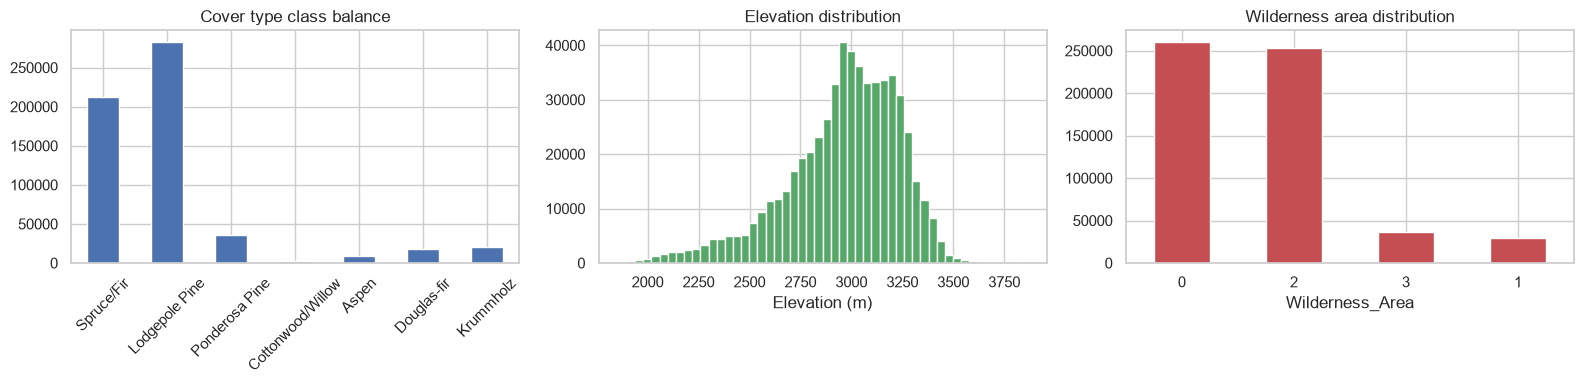

Class imbalance ratio (largest / smallest): 103.1x


In [5]:
COVER_TYPE_NAMES = {
    1: "Spruce/Fir", 2: "Lodgepole Pine", 3: "Ponderosa Pine", 4: "Cottonwood/Willow",
    5: "Aspen", 6: "Douglas-fir", 7: "Krummholz",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = y.value_counts().sort_index()
counts.index = [COVER_TYPE_NAMES[i] for i in counts.index]
counts.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Cover type class balance")
axes[0].tick_params(axis="x", rotation=45)

axes[1].hist(X["Elevation"], bins=50, color="#55A868")
axes[1].set_title("Elevation distribution")
axes[1].set_xlabel("Elevation (m)")

df["Wilderness_Area"].value_counts().plot(kind="bar", ax=axes[2], color="#C44E52")
axes[2].set_title("Wilderness area distribution")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(f"Class imbalance ratio (largest / smallest): {counts.max() / counts.min():.1f}x")


## 5. Train/Test Split

No context-size limit here — we train on the entire ~465,000-row pool and evaluate on the same
3,000-row held-out set used across all three companion notebooks. XGBoost's multiclass labels need
to be zero-indexed (`Cover_Type` ships as 1–7), so we shift them once, consistently, everywhere.


In [6]:
X_train_pool, X_test_pool, y_train_pool, y_test_pool = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train pool: {len(X_train_pool):,} rows | Test pool: {len(X_test_pool):,} rows")


def stratified_subsample(X, y, n, seed=42):
    idx, _ = train_test_split(np.arange(len(X)), train_size=min(n, len(X)), stratify=y, random_state=seed)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)


N_EVAL = 3000
X_eval, y_eval = stratified_subsample(X_test_pool, y_test_pool, N_EVAL)
print(f"Eval set: {len(X_eval):,} rows (shared across every model we test)")
print(y_eval.value_counts(normalize=True).round(3))


Train pool: 464,809 rows | Test pool: 116,203 rows


Eval set: 3,000 rows (shared across every model we test)
Cover_Type
2    0.488
1    0.365
3    0.061
7    0.035
6    0.030
5    0.016
4    0.005
Name: proportion, dtype: float64


In [7]:
# XGBoost's multiclass objective expects zero-indexed labels; Cover_Type is natively 1-7.
y_train_pool_xgb = y_train_pool - 1
y_eval_xgb = y_eval - 1


## 6. A Quick Baseline


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

logreg_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("num", StandardScaler(), NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ])),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

t0 = time.time()
logreg_pipe.fit(X_train_pool, y_train_pool)
logreg_pred = logreg_pipe.predict(X_eval)
logreg_proba = logreg_pipe.predict_proba(X_eval)
print(f"LogisticRegression fit on {len(X_train_pool):,} rows in {time.time() - t0:.1f}s")

results = {}


def score(name, y_true, pred, proba=None, classes=None):
    entry = {
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "f1_macro": f1_score(y_true, pred, average="macro"),
    }
    if proba is not None:
        entry["log_loss"] = log_loss(y_true, proba, labels=classes)
    results[name] = entry


score("LogisticRegression", y_eval, logreg_pred, logreg_proba, logreg_pipe.classes_)
display(pd.DataFrame(results).T.round(4))


LogisticRegression fit on 464,809 rows in 29.2s


,accuracy,balanced_accuracy,f1_macro,log_loss
LogisticRegression,0.7317,0.5237,0.5428,0.6285


## 7. Training XGBoost — Default vs. a Light Tuning Pass

To make good on "a *fully-tuned* XGBoost remains the undisputed king" rather than just running
defaults, we compare an untuned baseline configuration against a short randomized hyperparameter
search — a real (if deliberately time-boxed) tuning effort, not a single arbitrary guess.


In [9]:
X_train_enc = X_train_pool.copy()
X_eval_enc = X_eval.copy()
for c_ in CAT_COLS:
    X_train_enc[c_] = X_train_enc[c_].astype("category")
    X_eval_enc[c_] = X_eval_enc[c_].astype("category")

xgb_default = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.3,
    tree_method="hist", enable_categorical=True,
    objective="multi:softprob", num_class=7, random_state=42,
)

t0 = time.time()
xgb_default.fit(X_train_enc, y_train_pool_xgb)
default_time = time.time() - t0
pred_default = xgb_default.predict(X_eval_enc)
proba_default = xgb_default.predict_proba(X_eval_enc)

print(f"XGBoost (default-ish): fit on {len(X_train_enc):,} rows in {default_time:.1f}s")
score("XGBoost (default)", y_eval_xgb, pred_default, proba_default, list(range(7)))
display(pd.DataFrame(results).T.round(4))


XGBoost (default-ish): fit on 464,809 rows in 247.3s


,accuracy,balanced_accuracy,f1_macro,log_loss
LogisticRegression,0.7317,0.5237,0.5428,0.6285
XGBoost (default),0.9190,0.9248,0.9263,0.2171


In [10]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [6, 8, 10],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
}

# A real, time-boxed tuning pass: 3-fold CV over 8 random configurations on a 30,000-row
# subsample (tuning on the full 465,000-row pool would be prohibitively slow for a tutorial;
# the final model is still refit on the full pool with the winning configuration).
X_tune, _, y_tune, _ = train_test_split(X_train_enc, y_train_pool_xgb, train_size=30000,
                                          stratify=y_train_pool_xgb, random_state=42)

search = RandomizedSearchCV(
    xgb.XGBClassifier(tree_method="hist", enable_categorical=True, objective="multi:softprob",
                       num_class=7, random_state=42),
    param_distributions=param_dist, n_iter=8, cv=3, scoring="accuracy", random_state=42, n_jobs=-1,
)

t0 = time.time()
search.fit(X_tune, y_tune)
tune_time = time.time() - t0
print(f"RandomizedSearchCV (8 configs x 3-fold, 30,000-row subsample): {tune_time:.1f}s")
print("Best params:", search.best_params_)


RandomizedSearchCV (8 configs x 3-fold, 30,000-row subsample): 54.6s
Best params: {'subsample': 0.9, 'n_estimators': 400, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 1.0}


In [11]:
xgb_tuned = xgb.XGBClassifier(
    **search.best_params_, tree_method="hist", enable_categorical=True,
    objective="multi:softprob", num_class=7, random_state=42,
)

t0 = time.time()
xgb_tuned.fit(X_train_enc, y_train_pool_xgb)
tuned_time = time.time() - t0
pred_tuned = xgb_tuned.predict(X_eval_enc)
proba_tuned = xgb_tuned.predict_proba(X_eval_enc)

print(f"XGBoost (tuned): fit on {len(X_train_enc):,} rows in {tuned_time:.1f}s "
      f"(plus {tune_time:.1f}s tuning)")
score("XGBoost (tuned)", y_eval_xgb, pred_tuned, proba_tuned, list(range(7)))
display(pd.DataFrame(results).T.round(4))


XGBoost (tuned): fit on 464,809 rows in 71.2s (plus 54.6s tuning)


,accuracy,balanced_accuracy,f1_macro,log_loss
LogisticRegression,0.7317,0.5237,0.5428,0.6285
XGBoost (default),0.9190,0.9248,0.9263,0.2171
XGBoost (tuned),0.9767,0.9641,0.9605,0.0667


## 8. Native Feature Importance


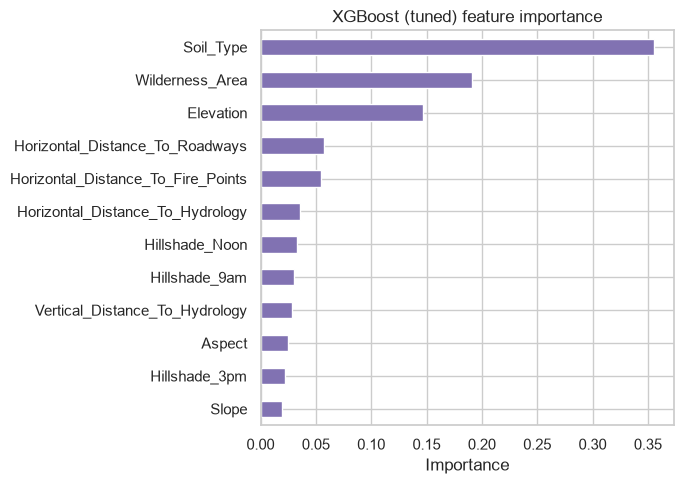

In [12]:
importances = pd.Series(xgb_tuned.feature_importances_, index=X_train_enc.columns).sort_values()
importances.plot(kind="barh", figsize=(7, 5), color="#8172B2", title="XGBoost (tuned) feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


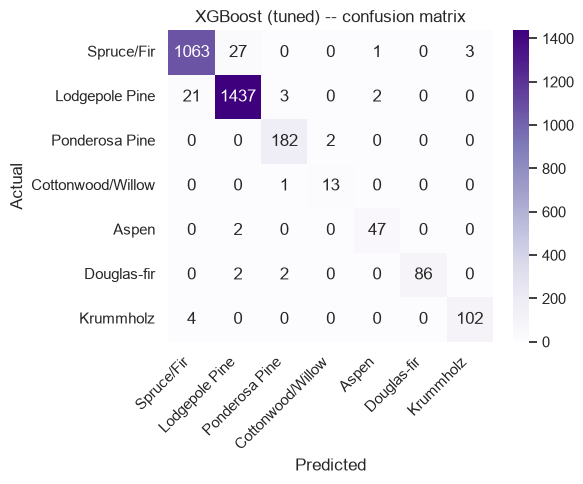

In [13]:
cm = confusion_matrix(y_eval_xgb, pred_tuned, labels=list(range(7)))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[COVER_TYPE_NAMES[i + 1] for i in range(7)],
            yticklabels=[COVER_TYPE_NAMES[i + 1] for i in range(7)])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost (tuned) -- confusion matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 9. Predictions for the New Patches


In [14]:
new_patches = pd.DataFrame([
    {"Elevation": 3200, "Aspect": 90, "Slope": 12, "Horizontal_Distance_To_Hydrology": 150,
     "Vertical_Distance_To_Hydrology": 20, "Horizontal_Distance_To_Roadways": 800,
     "Hillshade_9am": 220, "Hillshade_Noon": 230, "Hillshade_3pm": 140,
     "Horizontal_Distance_To_Fire_Points": 900, "Wilderness_Area": str(X_train_pool["Wilderness_Area"].mode()[0]),
     "Soil_Type": str(X_train_pool["Soil_Type"].mode()[0])},
    {"Elevation": 2400, "Aspect": 180, "Slope": 25, "Horizontal_Distance_To_Hydrology": 60,
     "Vertical_Distance_To_Hydrology": 5, "Horizontal_Distance_To_Roadways": 300,
     "Hillshade_9am": 200, "Hillshade_Noon": 225, "Hillshade_3pm": 160,
     "Horizontal_Distance_To_Fire_Points": 400, "Wilderness_Area": str(X_train_pool["Wilderness_Area"].mode()[0]),
     "Soil_Type": str(X_train_pool["Soil_Type"].mode()[0])},
])
for c_ in CAT_COLS:
    new_patches[c_] = new_patches[c_].astype("category")

new_proba = xgb_tuned.predict_proba(new_patches)
for i, row in new_patches.iterrows():
    top3_idx = np.argsort(new_proba[i])[::-1][:3]
    top3 = [(COVER_TYPE_NAMES[j + 1], new_proba[i][j]) for j in top3_idx]
    print(f"Patch {i + 1}: elevation={row['Elevation']}m, slope={row['Slope']}°")
    print("  Top predictions: " + ", ".join(f"{name} ({p:.2f})" for name, p in top3))
    print()


Patch 1: elevation=3200m, slope=12°
  Top predictions: Spruce/Fir (0.95), Lodgepole Pine (0.05), Krummholz (0.00)

Patch 2: elevation=2400m, slope=25°
  Top predictions: Lodgepole Pine (1.00), Spruce/Fir (0.00), Douglas-fir (0.00)



## 10. Practical Notes and Gotchas

- **Labels must be zero-indexed** for XGBoost's multiclass objective — `Cover_Type` ships as 1-7,
  so we shift every label by 1 consistently, in exactly one place, right after the train/test
  split, to avoid subtle off-by-one bugs downstream.
- **`enable_categorical=True` + `tree_method="hist"`** is the modern (v2.x+) way to hand XGBoost
  raw categorical columns directly — no manual one-hot encoding needed, matching CatBoost's and
  LightGBM's native categorical handling in the companion regression notebooks.
- **Tuning on a subsample, refitting on the full pool** is a real, practical pattern for large
  datasets: a full grid/randomized search over 465,000 rows would be far slower than a tutorial
  budget allows, but the winning hyperparameters from a smaller subsample transfer reasonably well
  to the full-data refit.
- **No context-size limit, no GPU requirement, no license restriction** — the three concrete
  advantages a classical GBM keeps over every foundation model in this notebook series.


In [15]:
display(pd.DataFrame(results).T.round(4))
print(f"\nXGBoost (default) wall-clock: {default_time:.1f}s | tuning: {tune_time:.1f}s | "
      f"tuned refit: {tuned_time:.1f}s")


,accuracy,balanced_accuracy,f1_macro,log_loss
LogisticRegression,0.7317,0.5237,0.5428,0.6285
XGBoost (default),0.9190,0.9248,0.9263,0.2171
XGBoost (tuned),0.9767,0.9641,0.9605,0.0667



XGBoost (default) wall-clock: 247.3s | tuning: 54.6s | tuned refit: 71.2s


## 11. Summary and References

XGBoost trained on the full ~465,000-row pool, with both a default-ish configuration and a
genuinely tuned one (via a time-boxed `RandomizedSearchCV`), on the same 7-class, imbalanced,
high-cardinality-categorical dataset used across this notebook series. Compare these numbers
against the companion TabPFN v3 and Mitra notebooks.

**References:**

- [github.com/dmlc/xgboost](https://github.com/dmlc/xgboost) — source code (Apache-2.0)
- [xgboost.readthedocs.io](https://xgboost.readthedocs.io/) — official documentation
- [pypi.org/project/xgboost](https://pypi.org/project/xgboost/)

- [Covertype dataset (UCI / scikit-learn)](https://scikit-learn.org/stable/datasets/real_world.html#forest-covertypes)
- [Blackard & Dean (1999), original dataset paper](https://doi.org/10.1016/S0168-1699(99)00046-0)
